In [208]:
#Importing all the required libraries and functions to call the Correlation and mean

from os.path import basename, exists
import numpy as np
import thinkstats2
import thinkplot

def download(url):
    
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

# downloading all the required data  
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/first.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/estimation.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/2002FemPreg.dat.gz")

In [210]:
import first
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

live, firsts, others = first.MakeFrames()
live = live.dropna(subset=['agepreg','totalwgt_lb'])

In [211]:
# Calculate covariance

def Cov(xs, ys, meanx=None, meany=None):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if meanx is None:
        meanx = np.mean(xs)
    if meany is None:
        meany = np.mean(ys)

    cov = np.dot(xs-meanx, ys-meany) / len(xs)
    return cov

In [212]:
# Calculate correlation

def Corr(xs, ys):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    meanx, varx = thinkstats2.MeanVar(xs)
    meany, vary = thinkstats2.MeanVar(ys)

    corr = Cov(xs, ys, meanx, meany) / np.sqrt(varx * vary)
    return corr

In [216]:
import pandas as pd

def SpearmanCorr(xs, ys):
    xranks = pd.Series(xs).rank()
    yranks = pd.Series(ys).rank()
    return Corr(xranks, yranks)

Exercise: In this chapter we used and median to estimate µ, and found that yields lower MSE. Also, we used and to estimate σ, and found that is biased and unbiased. Run similar experiments to see if and median are biased estimates of µ. Also check whether or yields a lower MSE.

In [219]:
# Get age and Preg weight in the age and weights variables.

ages = live.agepreg
weights = live.totalwgt_lb
print('Corr', Corr(ages, weights))
print('SpearmanCorr', SpearmanCorr(ages, weights))

Corr 0.06883397035410882
SpearmanCorr 0.09461004109658226


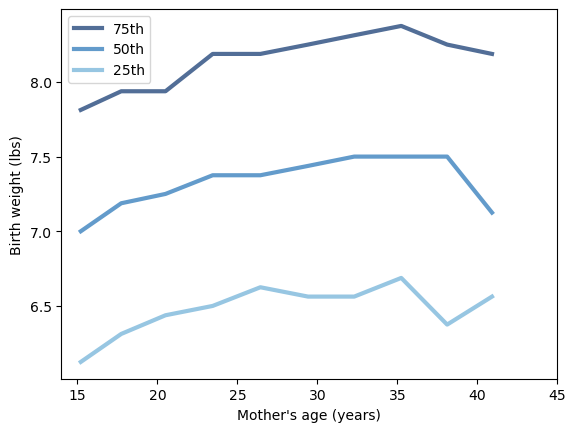

In [221]:
# Bin the data by Mother's age and plot percentiles of Birth weight for each bin.

def BinnedPercentiles(df):
    
    bins = np.arange(10, 48, 3)
    indices = np.digitize(df.agepreg, bins)
    groups = df.groupby(indices)

    ages = [group.agepreg.mean() for i, group in groups][1:-1]
    cdfs = [thinkstats2.Cdf(group.totalwgt_lb) for i, group in groups][1:-1]

    thinkplot.PrePlot(3)
    
    for percent in [75, 50, 25]:
        weights = [cdf.Percentile(percent) for cdf in cdfs]
        label = '%dth' % percent
        thinkplot.Plot(ages, weights, label=label)

    thinkplot.Config(
                     xlabel = "Mother's age (years)",
                     ylabel = "Birth weight (lbs)",
                     xlim = [14,45], 
                     legend = True
                    )
    
BinnedPercentiles(live)

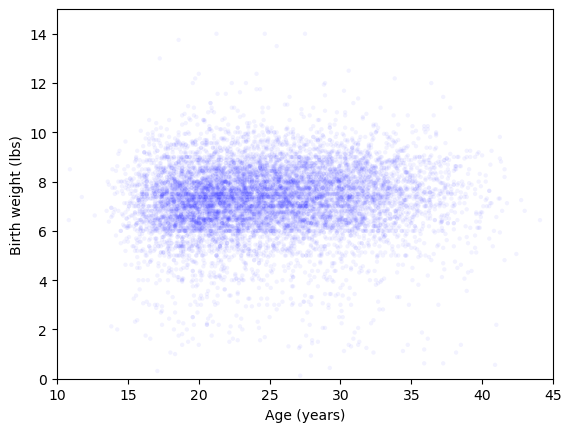

In [223]:
# Another representation of the chart for Mother's age and Birth weight using scatter's plot 

thinkplot.Scatter(ages, weights, alpha=0.05, s=10)
thinkplot.Config(xlabel='Age (years)',
                     ylabel='Birth weight (lbs)',
                     xlim=[10, 45],
                     ylim=[0, 15],
                     legend=False)

In [225]:
def MeanError(estimates, actual):
    """Computes the mean error of a sequence of estimates.

    estimate: sequence of numbers
    actual: actual value

    returns: float mean error
    """
    errors = [estimate-actual for estimate in estimates]
    return np.mean(errors)

In [227]:

import math
import random
import numpy as np


In [229]:
# Solution

def Estimate4(n=7, iters=100000):
    """Mean error for xbar and median as estimators of population mean.

    n: sample size
    iters: number of iterations
    """
    mu = 0
    sigma = 1

    means = []
    medians = []
    for _ in range(iters):
        xs = [random.gauss(mu, sigma) for i in range(n)]
        xbar = np.mean(xs)
        median = np.median(xs)
        means.append(xbar)
        medians.append(median)

    print('Experiment 1')
    print('mean error xbar', MeanError(means, mu))
    print('mean error median', MeanError(medians, mu))
    
Estimate4()

Experiment 1
mean error xbar -0.0013626813705219158
mean error median -0.0010686993693168486


In [230]:
#This function computes the root mean squared error of a sequence of estimates.

def RMSE(estimates, actual):
    """
    estimate: sequence of numbers
    actual: actual value
    
    returns: float RMSE
    """
    e2 = [(estimate-actual)**2 for estimate in estimates]
    mse = np.mean(e2)
    return math.sqrt(mse)

standard error 0.7797274917139879
confidence interval (1.280562743729896, 3.64762518509527)


0.7797274917139879

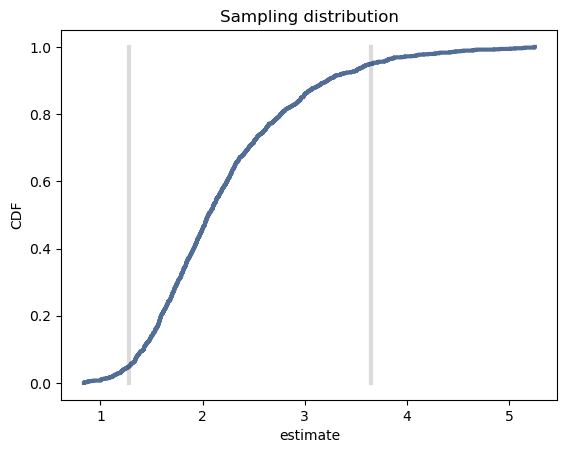

In [231]:
# Sampling distribution of L as an estimator of exponential parameter.

def SimulateSample(lam=2, n=10, iters=1000):
    """
        lam: parameter of an exponential distribution
        n: sample size
        iters: number of iterations
    """
    def VertLine(x, y=1):
        thinkplot.Plot([x, x], [0, y], color='0.8', linewidth=3)

    estimates = []
    for _ in range(iters):
        xs = np.random.exponential(1.0/lam, n)
        lamhat = 1.0 / np.mean(xs)
        estimates.append(lamhat)

    stderr = RMSE(estimates, lam)
    print('standard error', stderr)

    cdf = thinkstats2.Cdf(estimates)
    ci = cdf.Percentile(5), cdf.Percentile(95)
    print('confidence interval', ci)
    VertLine(ci[0])
    VertLine(ci[1])

    # plot the CDF
    thinkplot.Cdf(cdf)
    thinkplot.Config(xlabel='estimate',
                     ylabel='CDF',
                     title='Sampling distribution')

    return stderr

SimulateSample()

standard error 0.3049167714713084
confidence interval (2.555682236093407, 3.5538844653559827)


0.3049167714713084

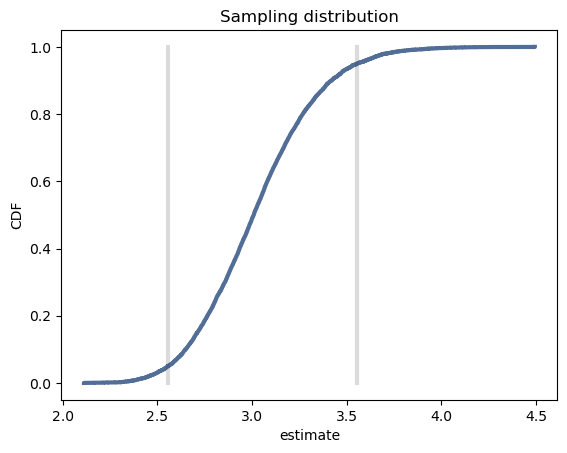

In [232]:
SimulateSample(3,100,10000)

standard error 0.09679119901767518
confidence interval (2.8496238859938336, 3.1657361760178615)


0.09679119901767518

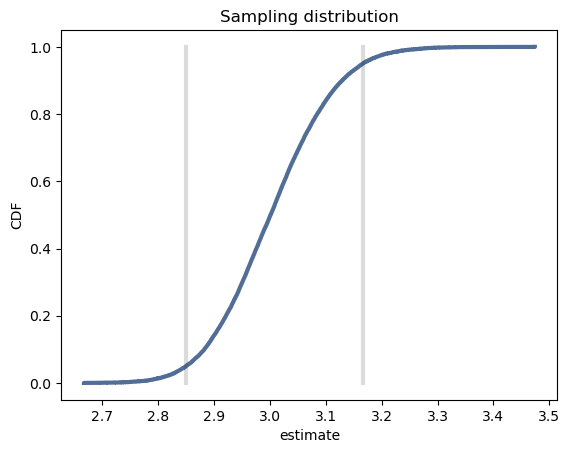

In [236]:
SimulateSample(3,1000,20000)